## Forecast 2026/27 + Model comparison (team models)

Train on historical team-season rows through 2025/26, then predict **points for each confirmed 2026/27 team** with `predict_team_points`.

We run all 20 squads and compare models on point forecasts. Combining predictions into a ranked table is documented in `05_backtest_models_comparison`.

**Model 1:** static latent `skill` (same strength across seasons). **Model 2:** persistent `team_skill` plus a newly simulated season deviation `tau_season · z` for 2026/27 — not the 2025/26 shock.


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from cmdstanpy import CmdStanModel

import importlib
import helping_functions as hf
importlib.reload(hf)

from helping_functions import (
    load_matches,
    load_season_tables,
    prepare_table_stan_static,
    prepare_table_stan_hierarchical,
    build_forecast_features,
    predict_team_points,
    build_predicted_table,
    compare_forecast_to_actual,
    forecast_season_summary,
    forecast_team_errors,
    print_forecast_season_summary,
    plot_forecast_team_errors,
    summarize_models,
    compare_models_team_errors,
    pl_2627_squad,
    STUDENT_T_NU,
    FORECAST_TRAIN_SEASONS,
    BACKTEST_TRAIN_SEASONS,
    BACKTEST_TEST_SEASON,
    teams_in_season,
)


In [20]:
matches = load_matches()
forecast_teams = pl_2627_squad(matches)
tables = load_season_tables(matches, FORECAST_TRAIN_SEASONS)

print(f"Forecast 2026/27: {len(forecast_teams)} teams")
for i, t in enumerate(forecast_teams, 1):
    print(f"  {i:2d}. {t}")


Forecast 2026/27: 20 teams
   1. Arsenal
   2. Aston Villa
   3. Bournemouth
   4. Brentford
   5. Brighton
   6. Chelsea
   7. Coventry
   8. Crystal Palace
   9. Everton
  10. Fulham
  11. Hull
  12. Ipswich
  13. Leeds
  14. Liverpool
  15. Man City
  16. Man United
  17. Newcastle
  18. Nott'm Forest
  19. Sunderland
  20. Tottenham


### Model 1 — static team model


In [ ]:
stan1, team_to_idx, _, feature_stats1 = prepare_table_stan_static(
    tables, FORECAST_TRAIN_SEASONS
)
stan1["nu"] = STUDENT_T_NU
fit1 = CmdStanModel(stan_file="stan/team_static.stan").sample(
    data=stan1, seed=42, chains=4, parallel_chains=4,
    iter_warmup=1500, iter_sampling=1500, adapt_delta=0.99, show_progress=True,
)
print(fit1.diagnose())


09:17:07 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

09:17:14 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [22]:
feat1 = build_forecast_features(
    matches, "2526", forecast_teams, FORECAST_TRAIN_SEASONS, feature_stats1
)

# Per-team point forecasts for all 20 clubs (Model 1)
pred1 = build_predicted_table(
    fit1, forecast_teams, team_to_idx, model="static", team_features=feat1, n_sims=800, seed=1
)
pred1 = pred1.rename(columns={"pos_median": "pos_m1", "pts_median": "pts_m1"})
pred1[["team", "pos_m1", "pts_m1", "pts_mean"]].head(20)


,team,pos_m1,pts_m1,pts_mean
0,Man City,1,76.330645,76.602096
1,Arsenal,2,73.618194,73.673460
2,Man United,3,71.795987,71.115493
3,Liverpool,4,61.244871,60.818556
4,Chelsea,5,58.761001,58.556988
5,Tottenham,6,57.266484,56.808911
6,Aston Villa,7,52.779934,52.387346
7,Brighton,8,52.690585,52.749769
8,Bournemouth,9,52.165250,52.102654
9,Brentford,10,52.070299,52.071561


### Model 2 — hierarchical team model

The forecast uses posterior `team_skill[team]` plus a newly simulated future-season deviation `tau_season · z` (`z ~ N(0, 1)`). It does **not** copy the 2025/26 season shock or average historical `skill[s, team]` into 2026/27.


In [23]:
stan2, team_to_idx2, _, season_to_idx, feature_stats2 = prepare_table_stan_hierarchical(
    tables, FORECAST_TRAIN_SEASONS
)
stan2["nu"] = STUDENT_T_NU
last_season_idx = season_to_idx["2526"]

fit2 = CmdStanModel(stan_file="stan/team_hierarchical.stan").sample(
    data=stan2, seed=42, chains=4, parallel_chains=4,
    iter_warmup=1500, iter_sampling=1500, adapt_delta=0.99, show_progress=True,
)
print(fit2.diagnose())


09:17:17 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

09:17:44 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [24]:
feat2 = build_forecast_features(
    matches, "2526", forecast_teams, FORECAST_TRAIN_SEASONS, feature_stats2
)

pred2 = build_predicted_table(
    fit2, forecast_teams, team_to_idx2, model="hierarchical", team_features=feat2, n_sims=800, seed=2
)
pred2 = pred2.rename(columns={"pos_median": "pos_m2", "pts_median": "pts_m2"})
pred2[["team", "pos_m2", "pts_m2", "pts_mean"]].head(20)


,team,pos_m2,pts_m2,pts_mean
0,Man City,1,75.594233,75.795585
1,Arsenal,2,74.182324,74.018989
2,Man United,3,71.845055,72.164289
3,Liverpool,4,61.787695,61.381125
4,Chelsea,5,59.110990,59.012679
5,Tottenham,6,58.886327,58.662534
6,Aston Villa,7,52.731642,52.703466
7,Brighton,8,52.332422,52.389031
8,Bournemouth,9,52.306292,52.107985
9,Brentford,10,52.054844,51.636358


### Side-by-side forecast 2026/27

Compare **median points** (model output). Positions in the table below are derived only by ranking predicted points.


In [25]:
comparison = pred1[["team", "pos_m1", "pts_m1"]].merge(
    pred2[["team", "pos_m2", "pts_m2"]], on="team"
)
comparison["pts_diff"] = comparison["pts_m1"] - comparison["pts_m2"]
comparison["pos_diff"] = comparison["pos_m1"] - comparison["pos_m2"]
comparison.sort_values("pts_m1", ascending=False)


,team,pos_m1,pts_m1,pos_m2,pts_m2,pts_diff,pos_diff
0,Man City,1,76.330645,1,75.594233,0.736412,0
1,Arsenal,2,73.618194,2,74.182324,-0.564130,0
2,Man United,3,71.795987,3,71.845055,-0.049068,0
3,Liverpool,4,61.244871,4,61.787695,-0.542825,0
4,Chelsea,5,58.761001,5,59.110990,-0.349989,0
5,Tottenham,6,57.266484,6,58.886327,-1.619844,0
6,Aston Villa,7,52.779934,7,52.731642,0.048292,0
7,Brighton,8,52.690585,8,52.332422,0.358163,0
8,Bournemouth,9,52.165250,9,52.306292,-0.141041,0
9,Brentford,10,52.070299,10,52.054844,0.015455,0


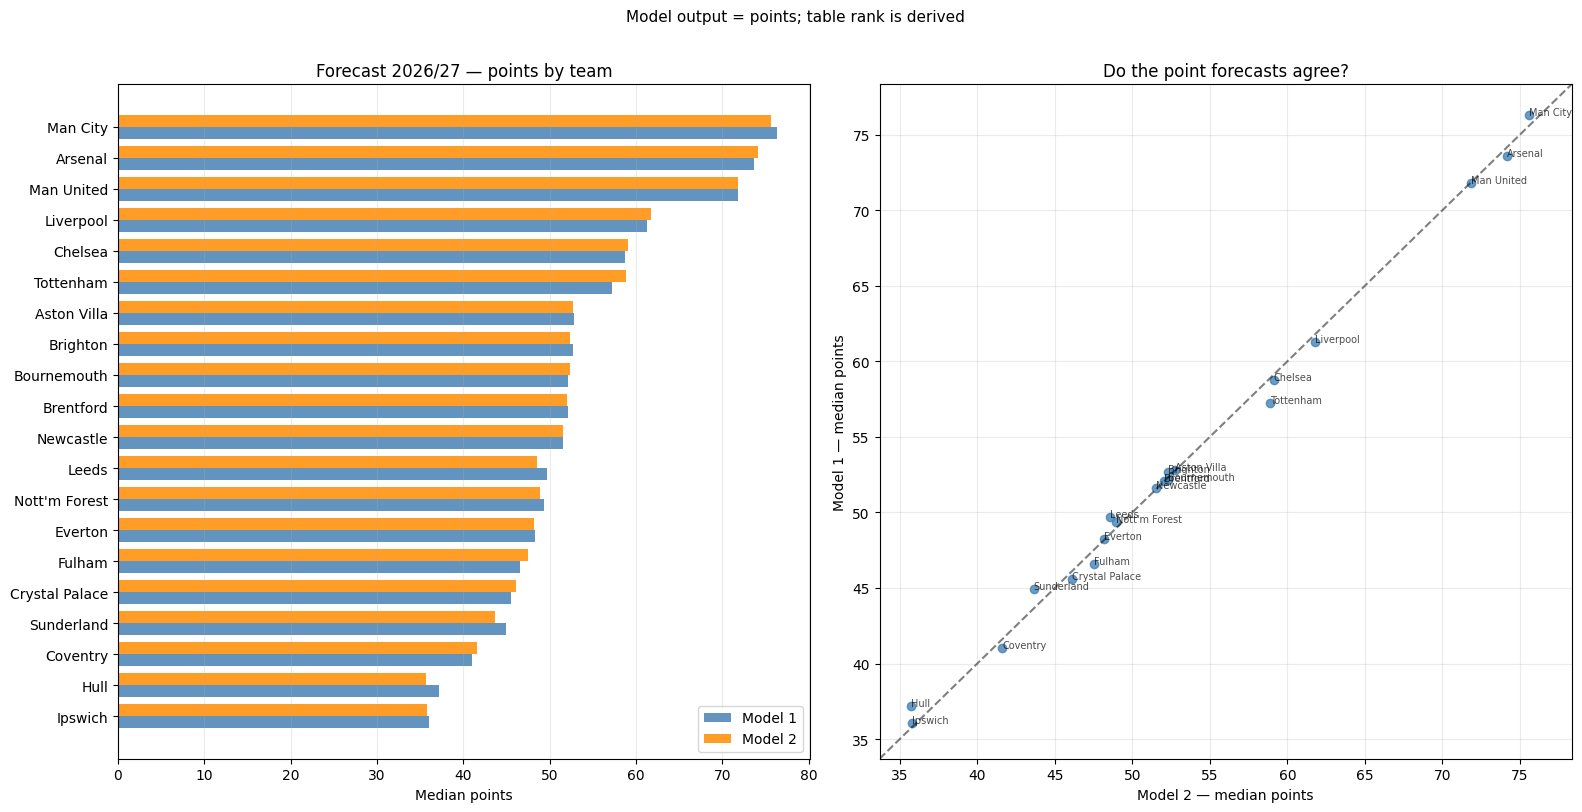

In [26]:
plot_df = comparison.sort_values("pts_m1", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: median points per team (what the models actually predict)
x = np.arange(len(plot_df))
w = 0.38
axes[0].barh(x - w / 2, plot_df["pts_m1"], height=w, label="Model 1", color="steelblue", alpha=0.85)
axes[0].barh(x + w / 2, plot_df["pts_m2"], height=w, label="Model 2", color="darkorange", alpha=0.85)
axes[0].set_yticks(x)
axes[0].set_yticklabels(plot_df["team"])
axes[0].set_xlabel("Median points")
axes[0].set_title("Forecast 2026/27 — points by team")
axes[0].legend(loc="lower right")
axes[0].grid(axis="x", alpha=0.25)

# Right: M1 vs M2 median points (derived positions omitted)
ax = axes[1]
ax.scatter(plot_df["pts_m2"], plot_df["pts_m1"], color="steelblue", alpha=0.8)
for _, r in plot_df.iterrows():
    ax.annotate(r["team"], (r["pts_m2"], r["pts_m1"]), fontsize=7, alpha=0.7)
lo = min(plot_df[["pts_m1", "pts_m2"]].min()) - 2
hi = max(plot_df[["pts_m1", "pts_m2"]].max()) + 2
ax.plot([lo, hi], [lo, hi], "k--", alpha=0.5)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel("Model 2 — median points")
ax.set_ylabel("Model 1 — median points")
ax.set_title("Do the point forecasts agree?")
ax.grid(alpha=0.25)

fig.suptitle("Model output = points; table rank is derived", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()


### WAIC / LOO (team-season rows)

Both information criteria are computed on the same historical unit: one team-season point total. Higher ELPD is better. The key question is not only which model has larger ELPD, but whether the difference is large relative to its uncertainty.

Interpretation rules used here:

- **PSIS-LOO:** prefer the model with higher `elpd_loo`, but treat differences smaller than the reported uncertainty as a practical tie.
- **Pareto k:** if all or nearly all rows have $k \leq 0.7$, LOO is reliable.
- **WAIC:** use as a secondary check. If WAIC warns about high posterior variance of log predictive densities, discuss the warning and lean more on PSIS-LOO plus backtest (`05_backtest_models_comparison`).


In [27]:
idata1 = az.from_cmdstanpy(fit1)
idata2 = az.from_cmdstanpy(fit2)

loo1 = az.loo(idata1, pointwise=True)
loo2 = az.loo(idata2, pointwise=True)
waic1 = az.waic(idata1)
waic2 = az.waic(idata2)

print("LOO Model 1:")
print(loo1)
print("\nLOO Model 2:")
print(loo2)
print(f"\nDelta ELPD LOO (M2 - M1): {loo2.elpd_loo - loo1.elpd_loo:.2f}")

k1 = loo1.pareto_k.values
k2 = loo2.pareto_k.values
print(f"M1 Pareto k <= 0.7: {(k1 <= 0.7).sum()}/{len(k1)}")
print(f"M2 Pareto k <= 0.7: {(k2 <= 0.7).sum()}/{len(k2)}")

print("\nWAIC Model 1:")
print(waic1)
print("\nWAIC Model 2:")
print(waic2)
print(f"\nDelta ELPD WAIC (M2 - M1): {waic2.elpd_waic - waic1.elpd_waic:.2f}")
print(f"WAIC warning M1: {getattr(waic1, 'warning', 'n/a')}")
print(f"WAIC warning M2: {getattr(waic2, 'warning', 'n/a')}")

loo_cmp = az.compare({"M1 static table": idata1, "M2 hierarchical table": idata2}, ic="loo")
waic_cmp = az.compare({"M1 static table": idata1, "M2 hierarchical table": idata2}, ic="waic")
print("\nLOO comparison:")
display(loo_cmp)
print("\nWAIC comparison:")
display(waic_cmp)


/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


LOO Model 1:
Computed from 4000 posterior samples and 340 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1302.39    13.82
p_loo       36.28        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      340  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%


LOO Model 2:
Computed from 6000 posterior samples and 340 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1302.64    16.08
p_loo       75.95        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      340  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%


Delta ELPD LOO (M2 - M1): -0.26
M1 Pareto k <= 0.7: 340/340
M2 Pareto k <= 0.7: 340/340

WAIC Model 1:
Computed from 4000 posterior samples and 340 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -1302.18    13.83
p_waic       36.07     

/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
M1 static table,0,-1302.389161,36.278160,0.000000,0.529379,13.821026,0.000000,False,log
M2 hierarchical table,1,-1302.644855,75.948803,0.255694,0.470621,16.077676,2.301106,False,log



WAIC comparison:


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
M2 hierarchical table,0,-1301.749512,75.053460,0.000000,0.598947,16.102598,0.000000,True,log
M1 static table,1,-1302.178975,36.067974,0.429463,0.401053,13.833964,2.313977,True,log


### Final assessment

- **Unit of prediction:** **one team** → points distribution (`predict_team_points`). League table = optional aggregation in `05_backtest_models_comparison`.
- **LOO result:** if Model 2 has only a very small ELPD advantage over Model 1, this is not strong evidence by itself. A difference around 1 ELPD point with uncertainty of several points should be treated as a practical tie.
- **WAIC result:** WAIC is useful as a secondary check, but warnings about high posterior variance of pointwise log predictive densities mean it may be unstable for some influential team-seasons. In that case, PSIS-LOO and backtest (`05_backtest_models_comparison`) should drive the decision.
- **Backtest result:** `05_backtest_models_comparison` evaluates **per-team point** prediction quality. If hierarchical is slightly better there while LOO/WAIC are tied, the hierarchical model is preferred cautiously.
- **Substantive choice:** Model 2 separates persistent club quality (`team_skill`) from one-season deviations (`tau_season`). Forecasts draw a **new** season shock for the target season; Model 1 keeps a single static skill. After this change, point forecasts may differ more between models than under the old mean-skill shortcut.

Final recommendation: report both forecasts when they differ materially, but use the hierarchical **team** model as the main model if its rerun diagnostics remain clean and the backtest advantage persists.
